In [ ]:
%load_ext autoreload
%autoreload 2

import sys, os
# os.environ['PATH']='/projects/bdne/spandey3/tex/texlive/bin/x86_64-linux:'+ os.environ['PATH']
# os.environ['PYTHONPATH']='/projects/bdne/spandey3/tex/texlive/bin/x86_64-linux:'
# os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION']='.98'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
import jax_cosmo.background as bkgrd
# os.environ["CUDA_VISIBLE_DEVICES"] = "0"
from jax.lib import xla_bridge
platform = xla_bridge.get_backend().platform
import jax
print(jax.local_device_count(), jax.device_count())
jax.config.update('jax_platform_name', platform)
jax.config.update("jax_enable_x64", True)
import jax
# Change the current working directory to the desired path
# os.chdir('/mnt/home/spandey/ceph/GODMAX/src/')
import matplotlib
import matplotlib.pyplot as pl
# set latex to false:
pl.rcParams['text.usetex'] = False
import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
sys.path.append((curr_path))
sys.path.append((abs_path_data))
sys.path.append((abs_path_results))
sys.path.append(abs_path_src)
import numpyro
numpyro.set_platform("gpu")
numpyro.enable_x64()
from jax import config
# config.update("jax_enable_x64", True)
# config.update("jax_enable_x64", False)
import scipy.interpolate as interp
import pickle as pk
import numpy as np
import jax.numpy as jnp
import colossus 
from jax import vmap, grad, pmap
import matplotlib.pyplot as pl
pl.rc('text', usetex=True)
import gc
# Palatino
# pl.rc('font', family='DejaVu Sans')
import ast
import yaml

import interpax
import asdf
import re
# nside = int(ast.literal_eval(sys.argv[1]))
# print('nside: ', nside)
# jdevice = int(ast.literal_eval(sys.argv[2]))
# print('jdevice: ', jdevice)
# Ndevices = int(ast.literal_eval(sys.argv[3]))
# print('Ndevices: ', Ndevices)
nside = 1024
jdevice = 0
Ndevices = 1

def split_array_power_ratio(arr, num_parts, power_val=0.5):
    n_total = arr.shape[0]
    j_values = np.arange(1, num_parts + 1)
    sqrt_j = j_values**power_val
    sum_of_sqrts = np.sum(sqrt_j)
    ideal_s1 = n_total / sum_of_sqrts
    ideal_sizes = ideal_s1 * sqrt_j
    int_sizes = np.floor(ideal_sizes).astype(int)
    remainder = n_total - np.sum(int_sizes)
    fractional_parts = ideal_sizes - int_sizes
    indices_to_increment = np.argsort(fractional_parts)[-remainder:]
    int_sizes[indices_to_increment] += 1
    split_indices = np.cumsum(int_sizes)[:-1]
    return np.split(arr, split_indices)


def read_yaml(file_path):
    with open(file_path, 'r') as file:
        data = yaml.safe_load(file)
    return data

def generate_dicts(data):
    sim_params_dict = data.get('sim_params', {})
    halo_params_dict = data.get('halo_params', {})
    analysis_dict = data.get('analysis', {})
    other_params_dict = data.get('other_params', {})
    return sim_params_dict, halo_params_dict, analysis_dict, other_params_dict

yaml_file_path = '/mnt/home/spandey/ceph/GODMAX/param_files/params_default.yaml'
data = read_yaml(yaml_file_path)
sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = generate_dicts(data)

halo_params_dict['rmin'] = 0.0001
halo_params_dict['rmax'] = 10.0
halo_params_dict['nr'] = 98
halo_params_dict['zmin'] = 0.01
halo_params_dict['zmax'] = 2.1
halo_params_dict['nz'] = 97
halo_params_dict['lg10_Mmin'] = 12.0
halo_params_dict['lg10_Mmax'] = 16.0
halo_params_dict['nM'] = 96

from godmax.get_B12_profile import Battaglia_12_16
import helpers.constants as constants
# cosmo_params_dict = {'w0':-1.0 ,'flat': True, 'H0': 69.0, 'Om0': 0.31, 'Ob0': 0.049, 'sigma8':0.81 ,'ns': 0.965}
cosmo_params_dict = {'w0':-1.0 ,'flat': True, 'H0': 67.74, 'Om0': 0.3089, 'Ob0': 0.0486, 'sigma8':0.8159 ,'ns': 0.9667}
# B12_test = Battaglia_12_16({'cosmo':cosmo_params_dict, 'init_power':False}, halo_params_dict)
import pathlib
import sys, os
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
sys.path.append((curr_path))
sys.path.append((abs_path_data))
sys.path.append((abs_path_results))
sys.path.append(abs_path_src)
import yaml
from godmax.get_radial_profiles import Profiles

def read_yaml(file_path):
    with open(file_path, 'r') as file:
        data = yaml.safe_load(file)
    return data

def generate_dicts(data):
    sim_params_dict = data.get('sim_params', {})
    halo_params_dict = data.get('halo_params', {})
    analysis_dict = data.get('analysis', {})
    other_params_dict = data.get('other_params', {})
    return sim_params_dict, halo_params_dict, analysis_dict, other_params_dict

yaml_file_path = '/mnt/home/spandey/ceph/GODMAX/param_files/params_default.yaml'
data = read_yaml(yaml_file_path)
sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = generate_dicts(data)

# halo_params_dict['rmin'] = 0.001
# halo_params_dict['rmax'] = 10.0
# halo_params_dict['nr'] = 126
# halo_params_dict['zmin'] = 0.01
# halo_params_dict['zmax'] = 2.1
# halo_params_dict['nz'] = 127
# halo_params_dict['lg10_Mmin'] = 12.0
# halo_params_dict['lg10_Mmax'] = 16.0
# halo_params_dict['nM'] = 128

cosmo_params_dict = {'w0':-1.0 ,'flat': True, 'H0': 67.74, 'Om0': 0.3089, 'Ob0': 0.0486, 'sigma8':0.8159 ,'ns': 0.9667}

Prof_test = Profiles(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)



# B12_test = Battaglia_12_16(sim_params_dict={'cosmo':cosmo_params_dict, 'init_power':True}, halo_params_dict=halo_params_dict)


# chi2z_interp = interpax.Interpolator1D(np.log(B12_test.chi_array), B12_test.z_array, extrap=True)
# import scipy.interpolate as interp1d
from scipy import interpolate
chi2z_interp = interpolate.interp1d(np.log(Prof_test.chi_array), Prof_test.z_array, fill_value="extrapolate")



from astropy.io import fits
import h5py as h5
import healpy as hp

data_dir = '/mnt/ceph/users/backlight/AbacusBacklight_base_c0000_ph000/lightcone_halos'
files = [f for f in os.listdir(data_dir)]
zlist = [re.findall(r'\d+\.\d+', f) for f in files]
zlist = np.array([item for sublist in zlist for item in sublist], dtype=float)
zlist = np.sort(zlist)

# zmin_top = 0.075
# zmax_top = 0.2

# zmin_top = 0.05
# zmax_top = 0.3

zmin_top = 0.3
zmax_top = 1.0


indsel = np.where((zlist > zmin_top) & (zlist < zmax_top))[0]

zlist = zlist[indsel]
for zval in zlist:
    with asdf.open(f'{data_dir}/z{zval:.3f}/lightcone_halo_info_000.asdf') as af:
        header = af['header']
        pos       = af['halo_lightcone']['InterpolatedPosition'][:]
        comovDis  = af['halo_lightcone']['InterpolatedComovingDist'][:]
        mass      = af['halo_lightcone']['InterpolatedN'][:]*header['ParticleMassMsun']
        vel       = af['halo_lightcone']['InterpolatedVelocity'][:]

    # vec=np.stack([X,Y,Z])
    #pos = np.array(vec.T)
    r = np.sum(pos**2,axis=-1)**.5
    r2d = np.sqrt(np.sum(pos[:,:2]**2,axis=-1))
    #zs = chi2z(r)
    #a_s = 1./(1+zs)
    RAS=np.arccos(pos[:,0].astype('float32')/r2d.astype('float32'))
    #RAS = np.arccos(pos[:,0]/r2d)
    RAS[pos[:,1]<0] *=-1. # correctly assign negative y values
    vec = (pos/r.reshape([-1,1]))
    DECS = np.arcsin(vec[:,2])

    vlos_all = np.sum(vel*vec,axis=-1)/(299792) # v is km/s. Convert to v/c

    z_all = chi2z_interp(np.log(comovDis))
    ra_all = np.array(RAS, dtype=np.float32) * 180/np.pi + 180.
    dec_all = np.array(DECS, dtype=np.float32) * 180/np.pi

    M200c_all = mass
    indsel = np.where((M200c_all<4e15) & (M200c_all>(10**12.5)))[0]
    ra_all = ra_all[indsel] 
    dec_all = dec_all[indsel]
    z_all = z_all[indsel]
    M200c_all = M200c_all[indsel]
    # M200m_all = M200m_all[indsel]
    vlos_all = vlos_all[indsel]
    print('total number of halos: ', len(M200c_all))

    argsort = np.flip(np.argsort(M200c_all))
    Nsel = (len(argsort)//Ndevices)*Ndevices
    argsort = argsort[:Nsel]
    Ngal_per_device = Nsel//Ndevices
    # argsort_here = argsort[jdevice*Ngal_per_device:(jdevice+1)*Ngal_per_device]
    argsort_split = split_array_power_ratio(argsort, Ndevices)
    argsort_here = argsort_split[jdevice]

    ra_all = ra_all[argsort_here]
    dec_all = dec_all[argsort_here]
    z_all = z_all[argsort_here]
    M200c_all = M200c_all[argsort_here]
    vlos_all = vlos_all[argsort_here]

    print('number of halos: ', len(M200c_all), ', mean log(M200c)', np.mean(np.log10(M200c_all)), ', mean z', np.mean(z_all))
    print('log10Mmin: ', np.min(np.log10(M200c_all)), ', log10Mmax: ', np.max(np.log10(M200c_all)))
    print('zmin: ', np.min(z_all), ', zmax: ', np.max(z_all))
    print('ra min: ', np.min(ra_all), ', ra max: ', np.max(ra_all))
    print('dec min: ', np.min(dec_all), ', dec max: ', np.max(dec_all))


    import warnings

    # Suppress all warnings
    warnings.filterwarnings("ignore")



    import pickle as pk
    import jax
    import scipy.interpolate as interp
    import healpy as hp
    import numpy as np
    from multiprocessing import Pool, cpu_count
    from astropy.io import fits
    # import constants
    import jax_cosmo.background as bkgrd
    from godmax.get_sim_maps import get_sim_map
    import h5py as h5


    jax.clear_caches()
    # nside = 4096
    # nside = 8192
    sdir = '/mnt/home/spandey/ceph/paste_godmax/GODMAX/results/backlight/'
    # save_kszmap_fname = sdir + f'tSZ_sim_B12_testv3_nside_{nside}.pkl'
    # save_map_fname = sdir + f'kSZ_sim_B16_testv11_nside_{nside}_split_{jdevice}_{Ndevices}.pkl'
    save_map_fname = sdir + f'allmaps_sim_B12_testv11_nside_{nside}_z_{zval}_split_{jdevice}_{Ndevices}_v2.pkl'
    # if not os.path.exists(save_kszmap_fname):
    halo_ra, halo_dec = ra_all, dec_all
    halo_z = z_all
    halo_m = M200c_all

    print('number of halos: ', len(halo_m))
    M_all = halo_m
    ra_all = halo_ra
    dec_all = halo_dec
    z_all = halo_z
    # vlos_all = np.zeros_like(z_all)
    nsel = len(M_all)

    # nh_max = 4e4
    # nh_max = 4e3
    if nside == 8192:
        nh_max = 4e3
    elif nside == 4096:
        nh_max = 5e4
    elif nside == 2048:
        nh_max = 5e5
    elif nside == 1024:
        nh_max = 5e6
    else:
        print('nside not supported')
    # nh_max = 1e5
    # nh_max = 2e6
    if nsel > nh_max:
        num_chunks = int(np.ceil(nsel / nh_max))
    else:
        num_chunks = 1



    map_test_rhom = np.zeros(12*nside**2, dtype=np.float32)
    map_test_ymap = np.zeros(12*nside**2, dtype=np.float32)
    map_test_ksz = np.zeros(12*nside**2, dtype=np.float32)
    map_test_tau = np.zeros(12*nside**2, dtype=np.float32)
    mock_gals_all = {}
    from tqdm import tqdm
    def process_halo(args):
        jhalo, ra_all_np, dec_all_np, z_all_chunk, M_all_chunk, vlos_all_chunk, halo_cat_R200c_np, halo_cat_DV_np, max_paint_R200c_factor, nside_local, pixel_dtype = args
        
        vec = hp.ang2vec(ra_all_np[jhalo], dec_all_np[jhalo], lonlat=True)
        nearby_angle = max_paint_R200c_factor * halo_cat_R200c_np[jhalo] / halo_cat_DV_np[jhalo]
        nearby_pix = hp.query_disc(nside_local, vec, nearby_angle)
        
        if len(nearby_pix) == 0:
            return None  # Handle empty results
        
        nearby_pix = np.asarray(nearby_pix, dtype=pixel_dtype)
        nearby_ra, nearby_dec = hp.pix2ang(nside_local, nearby_pix, lonlat=True)
        
        ra1, dec1 = np.radians(ra_all_np[jhalo]), np.radians(dec_all_np[jhalo])
        ra2, dec2 = np.radians(nearby_ra), np.radians(nearby_dec)
        
        dra = ra1 - ra2
        ddec = dec1 - dec2
        a = np.sin(ddec/2)**2 + np.cos(dec1) * np.cos(dec2) * np.sin(dra/2)**2
        theta = 2 * np.arcsin(np.sqrt(a))
        
        distances = (halo_cat_DV_np[jhalo] * theta).astype(np.float32)
        
        return (nearby_pix, distances, jhalo, len(nearby_pix))

    def concatenate_results(results, M_all_chunk, z_all_chunk, vlos_all_chunk, halo_cat_DV_np, halo_cat_R200c_np, max_paint_R200c_factor, pixel_dtype):
        if not results:
            return None
            
        lengths = np.array([result[3] for result in results], dtype=np.int32)
        total_length = lengths.sum()
        
        nearby_pix_all = np.empty(total_length, dtype=pixel_dtype)
        distances_pix_all = np.empty(total_length, dtype=np.float32)
        halo_indices = np.empty(total_length, dtype=np.int32)
        
        end_ind_all = np.cumsum(lengths)
        start_ind_all = np.concatenate([[0], end_ind_all[:-1]])
        
        for i, (start, end, result) in enumerate(zip(start_ind_all, end_ind_all, results)):
            nearby_pix_all[start:end] = result[0]
            distances_pix_all[start:end] = result[1]
            halo_indices[start:end] = result[2]
        
        halo_start_indices = np.array([result[2] for result in results], dtype=np.int32)
        logM_ind_all = np.log(M_all_chunk[halo_indices], dtype=np.float32)
        z_ind_all = z_all_chunk[halo_indices].astype(np.float32)
        vlos_ind_all = vlos_all_chunk[halo_indices].astype(np.float32)
        ang_distance_all = halo_cat_DV_np[halo_start_indices].astype(np.float32)
        rp_max_all = (max_paint_R200c_factor * halo_cat_R200c_np[halo_start_indices]).astype(np.float32)
        
        return (nearby_pix_all, distances_pix_all, start_ind_all, end_ind_all, 
                logM_ind_all, z_ind_all, vlos_ind_all, ang_distance_all, rp_max_all)

    def process_halos_in_batches(M_all_chunk, ra_all_chunk, dec_all_chunk, z_all_chunk, vlos_all_chunk, 
                            halo_cat_R200c, halo_cat_DA, max_paint_R200c_factor, nside, batch_size=1000):
        pixel_dtype = np.int32 if nside <= 8192 else np.int64
        
        ra_all_np = np.clip(np.array(ra_all_chunk, dtype=np.float32), 0.01, 359.99)
        dec_all_np = np.clip(np.array(dec_all_chunk, dtype=np.float32), -89.99, 89.99)
        z_all_np = np.array(z_all_chunk, dtype=np.float32)
        halo_cat_R200c_np = np.array(halo_cat_R200c, dtype=np.float32)
        halo_cat_DV_np = np.array(halo_cat_DA, dtype=np.float32)
        halo_vlos_np = np.array(vlos_all_chunk, dtype=np.float32)
        M_all_np = np.array(M_all_chunk, dtype=np.float32)
        
        n_halos = len(z_all_chunk)
        all_results = []
        
        for batch_start in range(0, n_halos, batch_size):
            batch_end = min(batch_start + batch_size, n_halos)
            print(f"Processing batch {batch_start//batch_size + 1}/{(n_halos-1)//batch_size + 1}")
            
            batch_args = []
            for jhalo in range(batch_start, batch_end):
                args = (jhalo, ra_all_np, dec_all_np, z_all_np, M_all_np, halo_vlos_np, 
                    halo_cat_R200c_np, halo_cat_DV_np, max_paint_R200c_factor, nside, pixel_dtype)
                batch_args.append(args)
            
            with Pool(cpu_count()) as pool:
                batch_results = pool.map(process_halo, batch_args)
            
            batch_results = [r for r in batch_results if r is not None]
            
            if batch_results:
                batch_M = M_all_np[batch_start:batch_end]
                batch_z = z_all_np[batch_start:batch_end] 
                batch_vlos = halo_vlos_np[batch_start:batch_end]
                batch_DV = halo_cat_DV_np[batch_start:batch_end]
                batch_R200c = halo_cat_R200c_np[batch_start:batch_end]
                
                batch_results_adjusted = []
                for result in batch_results:
                    pix, dist, halo_idx, n_pix = result
                    adjusted_idx = halo_idx  # Keep original index
                    batch_results_adjusted.append((pix, dist, adjusted_idx, n_pix))
                
                batch_data = concatenate_results(batch_results_adjusted, M_all_np, z_all_np, halo_vlos_np, 
                                            halo_cat_DV_np, halo_cat_R200c_np, max_paint_R200c_factor, pixel_dtype)
                
                if batch_data is not None:
                    all_results.append(batch_data)
            
            del batch_results, batch_args
            gc.collect()
        
        if not all_results:
            return None
            
        return final_concatenate_batches(all_results, pixel_dtype)

    def final_concatenate_batches(all_results, pixel_dtype):
        """Final concatenation of batch results"""
        total_pix = sum(len(result[0]) for result in all_results)
        total_halos = sum(len(result[2]) for result in all_results)
        
        final_nearby_pix = np.empty(total_pix, dtype=pixel_dtype)
        final_distances = np.empty(total_pix, dtype=np.float32)
        final_logM = np.empty(total_pix, dtype=np.float32)
        final_z = np.empty(total_pix, dtype=np.float32)
        final_vlos = np.empty(total_pix, dtype=np.float32)
        final_start_ind = np.empty(total_halos, dtype=np.int32)
        final_end_ind = np.empty(total_halos, dtype=np.int32)
        final_ang_dist = np.empty(total_halos, dtype=np.float32)
        final_rp_max = np.empty(total_halos, dtype=np.float32)
        
        pix_offset = 0
        halo_offset = 0
        
        for result in all_results:
            nearby_pix_all, distances_pix_all, start_ind_all, end_ind_all, logM_ind_all, z_ind_all, vlos_ind_all, ang_distance_all, rp_max_all = result
            
            n_pix_batch = len(nearby_pix_all)
            n_halo_batch = len(start_ind_all)
            
            final_nearby_pix[pix_offset:pix_offset + n_pix_batch] = nearby_pix_all
            final_distances[pix_offset:pix_offset + n_pix_batch] = distances_pix_all
            final_logM[pix_offset:pix_offset + n_pix_batch] = logM_ind_all
            final_z[pix_offset:pix_offset + n_pix_batch] = z_ind_all
            final_vlos[pix_offset:pix_offset + n_pix_batch] = vlos_ind_all
            
            final_start_ind[halo_offset:halo_offset + n_halo_batch] = start_ind_all + pix_offset
            final_end_ind[halo_offset:halo_offset + n_halo_batch] = end_ind_all + pix_offset
            final_ang_dist[halo_offset:halo_offset + n_halo_batch] = ang_distance_all
            final_rp_max[halo_offset:halo_offset + n_halo_batch] = rp_max_all
            
            pix_offset += n_pix_batch
            halo_offset += n_halo_batch
        
        return (final_nearby_pix, final_distances, final_start_ind, final_end_ind,
                final_logM, final_z, final_vlos, final_ang_dist, final_rp_max)


    for i in tqdm(range(num_chunks)):
        if i == num_chunks - 1:
            M_all_chunk = M_all[int(i*nh_max):]
            ra_all_chunk = ra_all[int(i*nh_max):]
            dec_all_chunk = dec_all[int(i*nh_max):]
            z_all_chunk = z_all[int(i*nh_max):]
            vlos_all_chunk = vlos_all[int(i*nh_max):]
        else:
            M_all_chunk = M_all[int(i*nh_max):int((i+1)*nh_max)]
            ra_all_chunk = ra_all[int(i*nh_max):int((i+1)*nh_max)]
            dec_all_chunk = dec_all[int(i*nh_max):int((i+1)*nh_max)]
            z_all_chunk = z_all[int(i*nh_max):int((i+1)*nh_max)]
            vlos_all_chunk = vlos_all[int(i*nh_max):int((i+1)*nh_max)]

        mock_params_dict = {}
        mock_params_dict['nside'] = nside
        mock_params_dict['get_ymap'] = True
        mock_params_dict['get_kSZmap'] = True
        mock_params_dict['get_taumap'] = True
        mock_params_dict['get_kappamap'] = True
        mock_params_dict['get_galmap'] = True
        mock_params_dict['smooth_profiles'] = True

        halo_cat_scale_fac = 1./(1. + z_all_chunk)
        halo_cat_rho_c_z = constants.RHO_CRIT_0_KPC3 * bkgrd.Esqr(Prof_test.cosmo_jax, halo_cat_scale_fac) * 1e9
        mdef_delta = 200
        halo_cat_rho_treshold = mdef_delta * halo_cat_rho_c_z
        halo_cat_R200c = (M_all_chunk * 3.0 / 4.0 / jnp.pi / halo_cat_rho_treshold)**(1.0 / 3.0)
        halo_cat_DA = bkgrd.angular_diameter_distance(Prof_test.cosmo_jax, halo_cat_scale_fac)
        max_paint_R200c_factor = 3.

        batch_size = int(nh_max//2)
        # print('processing batches')
        result = process_halos_in_batches(
            M_all_chunk, ra_all_chunk, dec_all_chunk, z_all_chunk, vlos_all_chunk,
            halo_cat_R200c, halo_cat_DA, max_paint_R200c_factor, nside, batch_size
        )
        # print('finished processing batches')

        if result is not None:
            nearby_pix_all, distances_pix_all, start_ind_all, end_ind_all, logM_ind_all, z_ind_all, vlos_ind_all, ang_distance_all, rp_max_all = result

            mock_params_dict['halo_z'] = jnp.array(z_all_chunk, dtype=jnp.float32)
            mock_params_dict['halo_ra'] = jnp.array(ra_all_chunk, dtype=jnp.float32)
            mock_params_dict['halo_dec'] = jnp.array(dec_all_chunk, dtype=jnp.float32)
            mock_params_dict['halo_M'] = jnp.array(M_all_chunk, dtype=jnp.float32)
            mock_params_dict['halo_vlos'] = jnp.array(vlos_all_chunk, dtype=jnp.float32)

            mock_params_dict['nearby_pix_all'] = jnp.array(nearby_pix_all)
            mock_params_dict['pix_prop_all'] = (jnp.array([np.log(distances_pix_all), z_ind_all, logM_ind_all, vlos_ind_all]).T).astype(jnp.float32)
            mock_params_dict['ang_distance_all'] = jnp.array(ang_distance_all)
            mock_params_dict['rp_max_all'] = jnp.array(rp_max_all)
            mock_params_dict['start_ind'] = jnp.array(start_ind_all, dtype=jnp.int32)
            mock_params_dict['end_ind'] = jnp.array(end_ind_all, dtype=jnp.int32)

            # print('generating mock map')
            mock_map_test = get_sim_map(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, mock_params_dict, Profiles_obj=Prof_test)
            # mock_map_test.ymap_final.block_until_ready()
            map_test_rhom += np.array(np.nan_to_num(mock_map_test.rhommap_final), dtype=np.float32)
            map_test_ymap += np.array(np.nan_to_num(mock_map_test.ymap_final), dtype=np.float32)
            map_test_ksz += np.array(np.nan_to_num(mock_map_test.kszmap_final), dtype=np.float32)
            map_test_tau += np.array(np.nan_to_num(mock_map_test.taumap_final), dtype=np.float32)
            mock_galaxy_catalog = mock_map_test.final_galaxy_catalog
            # print('finished generating mock map')
            mock_gals_all[i] = mock_galaxy_catalog
            del mock_map_test
            del mock_params_dict
            del result
            gc.collect()


        # del result, mock_params_dict
        if 'mock_map_test' in locals():
            del mock_map_test
        gc.collect()

    # Save results
    saved = {'mock_gals_all': mock_gals_all, 'map_rhom': map_test_rhom, 'map_ymap': map_test_ymap, 'map_ksz': map_test_ksz, 'map_tau': map_test_tau}
    pk.dump(saved, open(save_map_fname, 'wb'))
    del mock_gals_all
    gc.collect()




The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
1 1
total number of halos:  1252512
number of halos:  1252512 , mean log(M200c) 12.892013 , mean z 0.30421634487262883
log10Mmin:  12.500267 , log10Mmax:  15.273181
zmin:  0.29042340110377063 , zmax:  0.31795908331515604
ra min:  0.0 , ra max:  360.0
dec min:  -89.95577 , dec max:  89.93148
number of halos:  1252512


  0%|          | 0/1 [00:00<?, ?it/s]

Processing batch 1/1

--- Step 3: Populating 1252512 halos with galaxies ---
Population complete.

--- Step 4: Filtering padded catalog ---


100%|██████████| 1/1 [02:02<00:00, 122.78s/it]


total number of halos:  1499557
number of halos:  1499557 , mean log(M200c) 12.889168 , mean z 0.3345433695154024
log10Mmin:  12.500267 , log10Mmax:  15.274569
zmin:  0.3178918538419319 , zmax:  0.34998015077505024
ra min:  0.0 , ra max:  360.0
dec min:  -89.94066 , dec max:  89.836876
number of halos:  1499557


...

total number of halos:  2031294
number of halos:  2031294 , mean log(M200c) 12.882978 , mean z 0.3952007220131098
log10Mmin:  12.500267 , log10Mmax:  15.205882
zmin:  0.37913845501036003 , zmax:  0.41161918465151026
ra min:  0.0 , ra max:  360.0
dec min:  -89.74283 , dec max:  89.951546
number of halos:  2031294


  0%|          | 0/1 [00:00<?, ?it/s]

Processing batch 1/1


  0%|          | 0/1 [00:40<?, ?it/s]


KeyboardInterrupt: 

In [4]:
mock_gals_all = saved['mock_gals_all']




In [7]:
final_galaxy_catalog_cpu = jax.device_get(mock_gals_all[0])
header = ["RA", "Dec", "Redshift", "M200c", "Is_Central", "Is_Valid"]
print(f"{header[0]:>8s} {header[1]:>8s} {header[2]:>9s} {header[3]:>12s} {header[4]:>12s} {header[5]:>10s}")
for row in final_galaxy_catalog_cpu[:10]:
    print(f"{row[0]:8.3f} {row[1]:8.3f} {row[2]:9.4f} {row[3]:12.2e} {row[4]:12.1f} {row[5]:10.1f}")



      RA      Dec  Redshift        M200c   Is_Central   Is_Valid
  40.430   60.839    0.2858     1.44e+15          1.0        1.0
  39.713   61.028    0.2858     1.44e+15          0.0        1.0
 355.787  -25.254    0.2829     1.37e+15          1.0        1.0
 355.661  -25.630    0.2829     1.37e+15          0.0        1.0
 236.002  -15.305    0.2810     1.33e+15          1.0        1.0
 235.888  -15.597    0.2810     1.33e+15          0.0        1.0
 205.439   27.374    0.2772     1.30e+15          1.0        1.0
 205.371   27.282    0.2772     1.30e+15          0.0        1.0
 321.955  -53.270    0.2878     1.28e+15          1.0        1.0
 321.857  -53.493    0.2878     1.28e+15          0.0        1.0


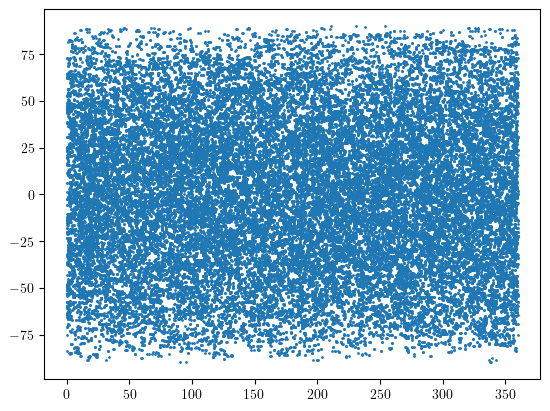

In [8]:
import matplotlib.pyplot as pl
pl.figure()
pl.scatter(final_galaxy_catalog_cpu[:,0], final_galaxy_catalog_cpu[:,1], s=1)
# pl.ylim(-95, -85)




In [2]:
# =============================================================================
# 1. IMPORTS AND SETUP
# =============================================================================
%load_ext autoreload
%autoreload 2
import os
import sys
import pathlib
import re
import gc
import yaml
import warnings
import time
from multiprocessing import Pool, cpu_count

# Suppress warnings
warnings.filterwarnings("ignore")

# --- Environment and JAX Configuration ---
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'

import jax
from jax.lib import xla_bridge
import jax.numpy as jnp
import jax_cosmo.background as bkgrd

platform = xla_bridge.get_backend().platform
jax.config.update('jax_platform_name', platform)
jax.config.update("jax_enable_x64", True)
print(f"JAX backend: {platform}, Total devices: {jax.device_count()}, Local devices: {jax.local_device_count()}")

import numpyro
numpyro.set_platform("gpu")
numpyro.enable_x64()

# --- Library Imports ---
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate
import asdf
import healpy as hp
from tqdm import tqdm
import pickle as pk

# --- Matplotlib Configuration ---
plt.rcParams['text.usetex'] = True
# To use Palatino font (if installed):
# plt.rcParams['font.family'] = 'Palatino'

# --- Add Project-Specific Paths ---
curr_path = pathlib.Path().absolute()
# Assuming the script is in a subdirectory like 'notebooks' or 'scripts'
# Adjust the path if the project structure is different.
project_base = curr_path.parents[1] 
abs_path_data = project_base / "data"
abs_path_src = project_base / "src"
abs_path_results = project_base / "results"

for path in [curr_path, abs_path_data, abs_path_src, abs_path_results]:
    sys.path.append(str(path))

# --- Import Custom Modules ---
from godmax.get_radial_profiles import Profiles
from godmax.get_sim_maps import setup_sim_map, get_sim_map
import helpers.constants as constants


# =============================================================================
# 2. HELPER FUNCTIONS
# =============================================================================

def split_array_power_ratio(arr, num_parts, power_val=0.5):
    """Splits an array into parts with sizes proportional to j^power_val."""
    n_total = arr.shape[0]
    j_values = np.arange(1, num_parts + 1)
    weights = j_values**power_val
    sum_of_weights = np.sum(weights)
    ideal_sizes = (n_total / sum_of_weights) * weights
    
    int_sizes = np.floor(ideal_sizes).astype(int)
    remainder = n_total - np.sum(int_sizes)
    
    # Distribute remainder based on fractional parts
    fractional_parts = ideal_sizes - int_sizes
    indices_to_increment = np.argsort(fractional_parts)[-remainder:]
    int_sizes[indices_to_increment] += 1
    
    split_indices = np.cumsum(int_sizes)[:-1]
    return np.split(arr, split_indices)

def read_yaml(file_path):
    """Reads a YAML file and returns its content."""
    with open(file_path, 'r') as file:
        return yaml.safe_load(file)

def generate_dicts(data):
    """Extracts parameter dictionaries from the main data dictionary."""
    sim_params_dict = data.get('sim_params', {})
    halo_params_dict = data.get('halo_params', {})
    analysis_dict = data.get('analysis', {})
    other_params_dict = data.get('other_params', {})
    return sim_params_dict, halo_params_dict, analysis_dict, other_params_dict

# --- Functions for Parallel Halo Processing ---

def process_halo(args):
    """Finds pixels near a single halo."""
    jhalo, ra_all_np, dec_all_np, halo_cat_R200c_np, halo_cat_DV_np, max_paint_R200c_factor, nside_local, pixel_dtype = args
    
    vec = hp.ang2vec(ra_all_np[jhalo], dec_all_np[jhalo], lonlat=True)
    # Angle subtended by the painting radius
    nearby_angle = max_paint_R200c_factor * halo_cat_R200c_np[jhalo] / halo_cat_DV_np[jhalo]
    nearby_pix = hp.query_disc(nside_local, vec, nearby_angle)
    
    if len(nearby_pix) == 0:
        return None
    
    nearby_pix = np.asarray(nearby_pix, dtype=pixel_dtype)
    nearby_ra, nearby_dec = hp.pix2ang(nside_local, nearby_pix, lonlat=True)
    
    # Haversine formula to calculate angular separation
    ra1, dec1 = np.radians(ra_all_np[jhalo]), np.radians(dec_all_np[jhalo])
    ra2, dec2 = np.radians(nearby_ra), np.radians(nearby_dec)
    
    a = np.sin((dec1 - dec2)/2)**2 + np.cos(dec1) * np.cos(dec2) * np.sin((ra1 - ra2)/2)**2
    theta = 2 * np.arcsin(np.sqrt(a))
    
    # Projected distance in Mpc
    distances = (halo_cat_DV_np[jhalo] * theta).astype(np.float32)
    
    return (nearby_pix, distances, jhalo, len(nearby_pix))

def concatenate_batch_results(results, M_all_chunk, z_all_chunk, vlos_all_chunk, halo_cat_DV_np, halo_cat_R200c_np, max_paint_R200c_factor, pixel_dtype):
    """Concatenates results from a single batch of parallel processing."""
    if not results:
        return None
        
    lengths = np.array([res[3] for res in results], dtype=np.int32)
    total_length = lengths.sum()
    
    # Pre-allocate arrays for efficiency
    nearby_pix_all = np.empty(total_length, dtype=pixel_dtype)
    distances_pix_all = np.empty(total_length, dtype=np.float32)
    halo_indices = np.empty(total_length, dtype=np.int32)
    
    end_indices = np.cumsum(lengths)
    start_indices = np.concatenate([[0], end_indices[:-1]])
    
    for i, (start, end, res) in enumerate(zip(start_indices, end_indices, results)):
        nearby_pix_all[start:end] = res[0]
        distances_pix_all[start:end] = res[1]
        halo_indices[start:end] = res[2]
    
    original_halo_indices = np.array([res[2] for res in results], dtype=np.int32)
    
    # Map pixel-level properties back from halo-level properties
    logM_ind_all = np.log(M_all_chunk[halo_indices]).astype(np.float32)
    z_ind_all = z_all_chunk[halo_indices].astype(np.float32)
    vlos_ind_all = vlos_all_chunk[halo_indices].astype(np.float32)
    
    # Map halo-level properties
    ang_distance_all = halo_cat_DV_np[original_halo_indices].astype(np.float32)
    rp_max_all = (max_paint_R200c_factor * halo_cat_R200c_np[original_halo_indices]).astype(np.float32)
    
    return (nearby_pix_all, distances_pix_all, start_indices, end_indices, 
            logM_ind_all, z_ind_all, vlos_ind_all, ang_distance_all, rp_max_all)

def final_concatenate_batches(all_results, pixel_dtype):
    """Final concatenation of results from all batches."""
    total_pix = sum(len(res[0]) for res in all_results)
    total_halos = sum(len(res[2]) for res in all_results)
    
    # Pre-allocate final arrays
    final_nearby_pix = np.empty(total_pix, dtype=pixel_dtype)
    final_distances = np.empty(total_pix, dtype=np.float32)
    final_logM = np.empty(total_pix, dtype=np.float32)
    final_z = np.empty(total_pix, dtype=np.float32)
    final_vlos = np.empty(total_pix, dtype=np.float32)
    final_start_ind = np.empty(total_halos, dtype=np.int32)
    final_end_ind = np.empty(total_halos, dtype=np.int32)
    final_ang_dist = np.empty(total_halos, dtype=np.float32)
    final_rp_max = np.empty(total_halos, dtype=np.float32)
    
    pix_offset, halo_offset = 0, 0
    for result in all_results:
        n_pix_batch = len(result[0])
        n_halo_batch = len(result[2])
        
        # Unpack batch results
        nearby_pix_b, dist_b, start_b, end_b, logM_b, z_b, vlos_b, ang_dist_b, rp_max_b = result
        
        # Fill pixel-level arrays
        final_nearby_pix[pix_offset : pix_offset + n_pix_batch] = nearby_pix_b
        final_distances[pix_offset : pix_offset + n_pix_batch] = dist_b
        final_logM[pix_offset : pix_offset + n_pix_batch] = logM_b
        final_z[pix_offset : pix_offset + n_pix_batch] = z_b
        final_vlos[pix_offset : pix_offset + n_pix_batch] = vlos_b
        
        # Fill halo-level arrays, adjusting indices with the offset
        final_start_ind[halo_offset : halo_offset + n_halo_batch] = start_b + pix_offset
        final_end_ind[halo_offset : halo_offset + n_halo_batch] = end_b + pix_offset
        final_ang_dist[halo_offset : halo_offset + n_halo_batch] = ang_dist_b
        final_rp_max[halo_offset : halo_offset + n_halo_batch] = rp_max_b
        
        pix_offset += n_pix_batch
        halo_offset += n_halo_batch
        
    return (final_nearby_pix, final_distances, final_start_ind, final_end_ind,
            final_logM, final_z, final_vlos, final_ang_dist, final_rp_max)

def process_halos_in_batches(M_all_chunk, ra_all_chunk, dec_all_chunk, z_all_chunk, vlos_all_chunk, 
                             halo_cat_R200c, halo_cat_DA, max_paint_R200c_factor, nside, batch_size=1000):
    """Manages the parallel processing of halos in manageable batches."""
    pixel_dtype = np.int32 if nside <= 8192 else np.int64
    
    ra_all_np = np.clip(np.array(ra_all_chunk, dtype=np.float32), 0.01, 359.99)
    dec_all_np = np.clip(np.array(dec_all_chunk, dtype=np.float32), -89.99, 89.99)
    halo_cat_R200c_np = np.array(halo_cat_R200c, dtype=np.float32)
    halo_cat_DV_np = np.array(halo_cat_DA, dtype=np.float32)
    
    n_halos = len(z_all_chunk)
    all_results = []
    
    with Pool(cpu_count()) as pool:
        for batch_start in range(0, n_halos, batch_size):
            batch_end = min(batch_start + batch_size, n_halos)
            print(f"Processing halo batch {batch_start//batch_size + 1}/{(n_halos - 1)//batch_size + 1}...")
            
            # Create arguments for each halo in the batch
            batch_args = [(jhalo, ra_all_np, dec_all_np, halo_cat_R200c_np, halo_cat_DV_np, 
                           max_paint_R200c_factor, nside, pixel_dtype) for jhalo in range(batch_start, batch_end)]
            
            # Map processing to the pool
            batch_results = pool.map(process_halo, batch_args)
            batch_results = [r for r in batch_results if r is not None]
            
            if batch_results:
                # Concatenate results from the current batch
                batch_data = concatenate_batch_results(batch_results, M_all_chunk, z_all_chunk, vlos_all_chunk, 
                                                       halo_cat_DV_np, halo_cat_R200c_np, max_paint_R200c_factor, pixel_dtype)
                if batch_data is not None:
                    all_results.append(batch_data)
            
            del batch_results, batch_args
            gc.collect()
    
    if not all_results:
        return None
        
    return final_concatenate_batches(all_results, pixel_dtype)




The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
JAX backend: gpu, Total devices: 1, Local devices: 1


In [3]:
# --- Timing Flag ---
PROFILE_TIMING = True

if PROFILE_TIMING:
    script_start_time = time.perf_counter()
    
# --- Analysis Parameters ---
nside = 1024
jdevice = 0
Ndevices = 1

# --- Load Configuration and Initialize Models ---
if PROFILE_TIMING:
    setup_start_time = time.perf_counter()

yaml_file_path = '/mnt/home/spandey/ceph/GODMAX/param_files/params_default.yaml'
data = read_yaml(yaml_file_path)
sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = generate_dicts(data)

# Override halo parameters for this analysis
halo_params_dict.update({
    'rmin': 0.0001, 'rmax': 10.0, 'nr': 48,
    'zmin': 0.01, 'zmax': 2.1, 'nz':27,
    'lg10_Mmin': 12.0, 'lg10_Mmax': 16.0, 'nM': 26
})

cosmo_params_dict = {'w0': -1.0, 'flat': True, 'H0': 67.74, 'Om0': 0.3089, 
                        'Ob0': 0.0486, 'sigma8': 0.8159, 'ns': 0.9667}

Prof_test = Profiles(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)

mock_params_dict_setup = {}
mock_params_dict_setup['nside'] = nside
mock_params_dict_setup['get_ymap'] = True
mock_params_dict_setup['get_kSZmap'] = True
mock_params_dict_setup['get_taumap'] = True
mock_params_dict_setup['get_kappamap'] = True
mock_params_dict_setup['get_galmap'] = True
mock_params_dict_setup['smooth_profiles'] = True
Prof_test = setup_sim_map(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, mock_params_dict_setup, Profiles_obj=Prof_test)

chi2z_interp = interpolate.interp1d(np.log(Prof_test.chi_array), Prof_test.z_array, fill_value="extrapolate")

if PROFILE_TIMING:
    setup_end_time = time.perf_counter()
    print(f"\n[PROFILE] Initial setup time: {setup_end_time - setup_start_time:.2f} seconds")

# --- Identify Redshift Slices to Process ---
data_dir = '/mnt/ceph/users/backlight/AbacusBacklight_base_c0000_ph000/lightcone_halos'
files = [f for f in os.listdir(data_dir)]
zlist = np.array(sorted(np.array([item for sublist in [re.findall(r'\d+\.\d+', f) for f in files] for item in sublist], dtype=float)))

zmin_top, zmax_top = 0.3, 1.0
indsel = np.where((zlist > zmin_top) & (zlist < zmax_top))[0]
zlist = zlist[indsel]

# --- Loop Over Each Redshift Slice ---
for zval in zlist:
    if PROFILE_TIMING:
        z_slice_start_time = time.perf_counter()
        
    print(f"\nProcessing redshift slice: z = {zval:.3f}")
    
    # Load halo data
    if PROFILE_TIMING:
        load_start_time = time.perf_counter()
    with asdf.open(f'{data_dir}/z{zval:.3f}/lightcone_halo_info_000.asdf') as af:
        header = af['header']
        pos = af['halo_lightcone']['InterpolatedPosition'][:]
        comovDis = af['halo_lightcone']['InterpolatedComovingDist'][:]
        mass = af['halo_lightcone']['InterpolatedN'][:] * header['ParticleMassMsun']
        vel = af['halo_lightcone']['InterpolatedVelocity'][:]
    if PROFILE_TIMING:
        load_end_time = time.perf_counter()
        print(f"[PROFILE] Data loading for z={zval:.3f}: {load_end_time - load_start_time:.2f} seconds")
        
    # Calculate RA, DEC, and v_los & Apply selections
    if PROFILE_TIMING:
        selection_start_time = time.perf_counter()
        
    ra_rad = np.arctan2(pos[:, 1], pos[:, 0])
    r = np.sqrt(np.sum(pos**2, axis=-1))
    dec_rad = np.arcsin(pos[:, 2] / r)
    ra_deg, dec_deg = np.rad2deg(ra_rad), np.rad2deg(dec_rad)
    ra_all, dec_all = (ra_deg + 360) % 360, dec_deg
    
    vec = pos / r[:, np.newaxis]
    vlos_all = np.sum(vel * vec, axis=-1)  # v
    
    z_all = chi2z_interp(np.log(comovDis))
    M200c_all = mass

    indsel = np.where((M200c_all < 4e15) & (M200c_all > (10**12.0)))[0]
    argsort = np.flip(np.argsort(M200c_all[indsel]))
    Nsel = (len(argsort) // Ndevices) * Ndevices
    argsort = argsort[:Nsel]
    
    argsort_split = split_array_power_ratio(argsort, Ndevices)
    argsort_here = argsort_split[jdevice]
    final_indices = indsel[argsort_here]

    ra_all, dec_all, z_all, M200c_all, vlos_all = (
        ra_all[final_indices], dec_all[final_indices], z_all[final_indices], 
        M200c_all[final_indices], vlos_all[final_indices]
    )
    
    if PROFILE_TIMING:
        selection_end_time = time.perf_counter()
        print(f"[PROFILE] Halo selection & processing for z={zval:.3f}: {selection_end_time - selection_start_time:.2f} seconds")

    print(f"Number of halos for this device: {len(M200c_all)}")
    print(f"Mean log(M200c): {np.mean(np.log10(M200c_all)):.2f}, Mean z: {np.mean(z_all):.2f}")
    
    # --- Chunking and Map Generation ---
    nh_max_map = {8192: 4e3, 4096: 5e4, 2048: 5e5, 1024: 1e7}
    nh_max = nh_max_map.get(nside, 1e5) # Default if nside not in map
    nsel = len(M200c_all)
    num_chunks = int(np.ceil(nsel / nh_max)) if nsel > nh_max else 1
    
    map_rhom, map_ymap, map_ksz, map_tau = (np.zeros(12 * nside**2, dtype=np.float32) for _ in range(4))
    mock_gals_all = {}
    
    for i in tqdm(range(num_chunks), desc=f"Painting maps for z={zval:.3f}"):
        start, end = int(i * nh_max), int((i + 1) * nh_max)
        M_chunk, ra_chunk, dec_chunk, z_chunk, vlos_chunk = (
            M200c_all[start:end], ra_all[start:end], dec_all[start:end],
            z_all[start:end], vlos_all[start:end]
        )
        
        scale_fac = 1. / (1. + z_chunk)
        rho_c_z = constants.RHO_CRIT_0_KPC3 * bkgrd.Esqr(Prof_test.cosmo_jax, scale_fac) * 1e9
        rho_treshold = 200 * rho_c_z
        R200c = (M_chunk * 3.0 / (4.0 * jnp.pi * rho_treshold))**(1.0 / 3.0)
        DA = bkgrd.angular_diameter_distance(Prof_test.cosmo_jax, scale_fac)
        
        if PROFILE_TIMING:
            pixel_finding_start_time = time.perf_counter()
        
        max_paint_R200c_factor = 3.0
        batch_size = int(nh_max // 2) if nh_max > 2 else 1
        result = process_halos_in_batches(
            M_chunk, ra_chunk, dec_chunk, z_chunk, vlos_chunk,
            R200c, DA, max_paint_R200c_factor, nside, batch_size
        )
        
        if PROFILE_TIMING:
            pixel_finding_end_time = time.perf_counter()
            print(f"\n[PROFILE] Chunk {i+1}/{num_chunks} - Pixel finding: {pixel_finding_end_time - pixel_finding_start_time:.2f} seconds")
        
        if result:
            mock_params_dict = {
                **mock_params_dict_setup,
                'halo_z': jnp.array(z_chunk, dtype=jnp.float32),
                'halo_ra': jnp.array(ra_chunk, dtype=jnp.float32),
                'halo_dec': jnp.array(dec_chunk, dtype=jnp.float32),
                'halo_M': jnp.array(M_chunk, dtype=jnp.float32),
                'halo_vlos': jnp.array(vlos_chunk, dtype=jnp.float32),
                'nearby_pix_all': jnp.array(result[0]),
                'start_ind': jnp.array(result[2], dtype=jnp.int32),
                'end_ind': jnp.array(result[3], dtype=jnp.int32),
                'pix_prop_all': (jnp.array([np.log(result[1]), result[5], result[4], result[6]]).T).astype(jnp.float32),
                'ang_distance_all': jnp.array(result[7]),
                'rp_max_all': jnp.array(result[8]),
                'profile_timing': PROFILE_TIMING
            }
            
            if PROFILE_TIMING:
                map_gen_start_time = time.perf_counter()
            
            mock_map = get_sim_map(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, mock_params_dict, Profiles_obj=Prof_test)
            
            map_rhom += np.nan_to_num(mock_map.rhommap_final)
            map_ymap += np.nan_to_num(mock_map.ymap_final)
            map_ksz += np.nan_to_num(mock_map.kszmap_final)
            map_tau += np.nan_to_num(mock_map.taumap_final)
            mock_gals_all[i] = mock_map.final_galaxy_catalog
            
            if PROFILE_TIMING:
                map_gen_end_time = time.perf_counter()
                print(f"[PROFILE] Chunk {i+1}/{num_chunks} - JAX map generation: {map_gen_end_time - map_gen_start_time:.2f} seconds")
            
            del mock_map, mock_params_dict, result
            jax.clear_caches()
            gc.collect()

    # Save results for the current redshift slice
    if PROFILE_TIMING:
        save_start_time = time.perf_counter()
        
    sdir = '/mnt/home/spandey/ceph/paste_godmax/GODMAX/results/backlight/'
    os.makedirs(sdir, exist_ok=True)
    save_map_fname = f'{sdir}/allmaps_sim_B12_nside{nside}_z{zval:.3f}_split{jdevice}of{Ndevices}.pkl'
    
    saved_data = {'mock_gals_all': mock_gals_all, 'map_rhom': map_rhom, 
                    'map_ymap': map_ymap, 'map_ksz': map_ksz, 'map_tau': map_tau}
    
    with open(save_map_fname, 'wb') as f:
        pk.dump(saved_data, f)
    
    if PROFILE_TIMING:
        save_end_time = time.perf_counter()
        print(f"[PROFILE] Saving results for z={zval:.3f}: {save_end_time - save_start_time:.2f} seconds")
        
    print(f"Results for z={zval:.3f} saved to {save_map_fname}")
    
    if PROFILE_TIMING:
        z_slice_end_time = time.perf_counter()
        print(f"[PROFILE] TOTAL TIME for z-slice {zval:.3f}: {z_slice_end_time - z_slice_start_time:.2f} seconds")
        
    del saved_data, mock_gals_all
    gc.collect()

if PROFILE_TIMING:
    script_end_time = time.perf_counter()
    print(f"\n[PROFILE] TOTAL SCRIPT EXECUTION TIME: {script_end_time - script_start_time:.2f} seconds")





[PROFILE] Initial setup time: 99.47 seconds

Processing redshift slice: z = 0.304
[PROFILE] Data loading for z=0.304: 5.64 seconds
[PROFILE] Halo selection & processing for z=0.304: 2.19 seconds
Number of halos for this device: 3846670
Mean log(M200c): 12.43, Mean z: 0.31


Painting maps for z=0.304:   0%|          | 0/1 [00:00<?, ?it/s]

Processing halo batch 1/1...

[PROFILE] Chunk 1/1 - Pixel finding: 36.63 seconds

--- JAX Map Generation Timing Profile ---
setup_common                       : 1.9426 seconds
setup_tau_interpolator             : 0.3069 seconds
ymap_generation_and_assembly       : 3.9963 seconds
ksz_map_generation_and_assembly    : 4.0903 seconds
tau_map_generation_and_assembly    : 4.0433 seconds
kappa_map_generation_and_assembly  : 4.0088 seconds
galaxy_ppf_interpolator_creation   : 0.3130 seconds
galaxy_population                  : 4.6641 seconds
galaxy_catalog_filtering           : 0.4142 seconds
total_execution                    : 23.7935 seconds
---------------------------------------

[PROFILE] Chunk 1/1 - JAX map generation: 24.13 seconds


Painting maps for z=0.304: 100%|██████████| 1/1 [01:03<00:00, 63.26s/it]


[PROFILE] Saving results for z=0.304: 0.85 seconds
Results for z=0.304 saved to /mnt/home/spandey/ceph/paste_godmax/GODMAX/results/backlight//allmaps_sim_B12_nside1024_z0.304_split0of1.pkl
[PROFILE] TOTAL TIME for z-slice 0.304: 71.97 seconds

Processing redshift slice: z = 0.334
[PROFILE] Data loading for z=0.334: 5.95 seconds
[PROFILE] Halo selection & processing for z=0.334: 2.69 seconds
Number of halos for this device: 4633015
Mean log(M200c): 12.43, Mean z: 0.33


...

Processing halo batch 1/2...
Processing halo batch 2/2...

[PROFILE] Chunk 1/1 - Pixel finding: 122.09 seconds

--- JAX Map Generation Timing Profile ---
setup_common                       : 2.3209 seconds
setup_tau_interpolator             : 0.4343 seconds
ymap_generation_and_assembly       : 4.6616 seconds
ksz_map_generation_and_assembly    : 4.5677 seconds
tau_map_generation_and_assembly    : 4.4222 seconds
kappa_map_generation_and_assembly  : 4.3297 seconds
galaxy_ppf_interpolator_creation   : 0.3806 seconds
galaxy_population                  : 4.9961 seconds
galaxy_catalog_filtering           : 0.3110 seconds
total_execution                    : 26.4375 seconds
---------------------------------------

[PROFILE] Chunk 1/1 - JAX map generation: 26.77 seconds


Painting maps for z=0.431: 100%|██████████| 1/1 [02:31<00:00, 151.34s/it]


[PROFILE] Saving results for z=0.431: 1.24 seconds
Results for z=0.431 saved to /mnt/home/spandey/ceph/paste_godmax/GODMAX/results/backlight//allmaps_sim_B12_nside1024_z0.431_split0of1.pkl
[PROFILE] TOTAL TIME for z-slice 0.431: 168.13 seconds

Processing redshift slice: z = 0.466
[PROFILE] Data loading for z=0.466: 12.44 seconds
[PROFILE] Halo selection & processing for z=0.466: 5.23 seconds
Number of halos for this device: 8945496
Mean log(M200c): 12.42, Mean z: 0.46


Painting maps for z=0.466:   0%|          | 0/1 [00:00<?, ?it/s]2025-09-27 14:23:14.188469: W external/xla/xla/tsl/framework/bfc_allocator.cc:501] Allocator (GPU_0_bfc) ran out of memory trying to allocate 17.06GiB (rounded to 18320375808)requested by op 
2025-09-27 14:23:14.188678: W external/xla/xla/tsl/framework/bfc_allocator.cc:512] *****************************__________________________________________*****_*____________________**
E0927 14:23:14.188703 1392991 pjrt_stream_executor_client.cc:3045] Execution of replica 0 failed: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 18320375808 bytes. [tf-allocator-allocation-error='']
Painting maps for z=0.466:   0%|          | 0/1 [00:10<?, ?it/s]


XlaRuntimeError: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 18320375808 bytes.